<a href="https://colab.research.google.com/github/Dr-Isam-ALJAWARNEH/fds-project-airnav/blob/main/Exploratory_Analysis_and_Spatial_Modeling_of_Air_Quality_and_Mobility_Patterns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EDA

Correlation

Clustering & Regression

Time/sample vs. RMSE

Geohas:
-Spatial grouping

-Clustering by location

-Heatmaps, pivot tables, etc.

In [1]:
# Step 1: Install all required libraries
!pip install datascience h3 pandas matplotlib seaborn scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 30.2 MB/s eta 0:00:00


In [2]:
# Step 2: Upload the cleaned CSV file
from google.colab import files
uploaded = files.upload()

Saving Merged_Cleaned_CSV.csv to Merged_Cleaned_CSV.csv


In [3]:
# Step 3: Load the uploaded CSV into a pandas DataFrame and convert it to a datascience Table
import pandas as pd
from datascience import Table

# Extract the uploaded file name
csv_file = list(uploaded.keys())[0]

# Read the CSV using pandas
df = pd.read_csv(csv_file)

# Convert pandas DataFrame to datascience Table for easier display/preview
table = Table.from_df(df)

# Display the first 5 rows in table format
table.show(5)

# Expected output: A nicely formatted interactive table with 5 rows and all columns from your dataset,
# such as: time, latitude, longitude, bin0–bin23, temperature, humidity, pm25, etc.

sensorid,time,latitude,longitude,bin0,bin1,bin2,bin3,bin4,bin5,bin6,bin7,bin8,bin9,bin10,bin11,bin12,bin13,bin14,bin15,bin16,bin17,bin18,bin19,bin20,bin21,bin22,bin23,temperature,humidity,pm25,pm1,pm10,geometry,geohash
NYCP1_01A,1579618560,40.8472,-73.8701,23,1,2,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,16.3,15.2,5.91,1.44,11.35,"POLYGON ((-73.84859700000018 40.871670000000115, -73.845 ...",dr72rh12
NYCP1_01A,1579618560,40.8472,-73.8701,18,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,16.2,15.1,1.18,1.05,1.18,"POLYGON ((-73.84859700000018 40.871670000000115, -73.845 ...",dr72rh12
NYCP1_01A,1579618560,40.8472,-73.8701,18,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,16.1,15.1,0.76,0.74,0.76,"POLYGON ((-73.84859700000018 40.871670000000115, -73.845 ...",dr72rh12
NYCP1_01A,1579618560,40.8472,-73.8701,18,1,2,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,16.1,15.2,4.48,1.15,47.36,"POLYGON ((-73.84859700000018 40.871670000000115, -73.845 ...",dr72rh12
NYCP1_01A,1579618560,40.8472,-73.8701,20,3,0,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,16,15.2,5.77,2.13,6.18,"POLYGON ((-73.84859700000018 40.871670000000115, -73.845 ...",dr72rh12


In [4]:
# Step 4: Display summary statistics for all numeric columns
# This includes count, mean, std deviation, min, 25%, 50%, 75%, and max values.
print("Descriptive Statistics:")
display(df.describe())

# Expected output:
# A table showing statistical summaries (mean, std, min, max, etc.)
# for columns like latitude, longitude, bin0–bin23, temperature, humidity, pm25, pm1, pm10, and Cluster.

Descriptive Statistics:


,time,latitude,longitude,bin0,bin1,bin2,bin3,bin4,bin5,bin6,...,bin19,bin20,bin21,bin22,bin23,temperature,humidity,pm25,pm1,pm10
count,1.183660e+05,118366.000000,118366.000000,118366.000000,118366.000000,118366.00000,118366.000000,118366.000000,118366.000000,118366.000000,...,118366.000000,118366.000000,118366.000000,118366.000000,118366.000000,118366.000000,118366.000000,118366.000000,118366.000000,118366.000000
mean,1.580375e+09,40.825519,-73.891859,44.776921,8.278129,2.93477,1.036657,0.989245,0.726129,0.623760,...,0.417316,0.417231,0.417079,0.417003,0.417704,8.161955,50.167722,7.383615,3.395490,24.310309
std,5.354787e+05,0.029119,0.025838,151.516586,77.685944,72.74785,71.796260,71.780631,71.722227,71.717432,...,71.710933,71.710933,71.710932,71.710932,71.710937,5.611649,21.116511,20.590431,6.518796,299.426051
min,1.579562e+09,40.008129,-74.009636,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,-7.900000,6.400000,0.000000,0.000000,0.000000
25%,1.579801e+09,40.815178,-73.898407,9.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,35.100000,0.910000,0.720000,0.910000
50%,1.580330e+09,40.820999,-73.890053,21.000000,3.000000,1.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,7.200000,46.200000,3.030000,1.670000,3.230000
75%,1.580824e+09,40.846985,-73.872093,57.000000,7.000000,2.00000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,11.000000,64.700000,7.720000,3.840000,12.360000
max,1.581927e+09,40.913586,-73.795425,18441.000000,12336.000000,12336.00000,12336.000000,12336.000000,12336.000000,12336.000000,...,12336.000000,12336.000000,12336.000000,12336.000000,12336.000000,39.900000,104.200000,3267.020000,213.240000,87341.710000


In [5]:
# Step 4: Display summary statistics for all numeric columns
# This includes count, mean, std deviation, min, 25%, 50%, 75%, and max values.
print("Descriptive Statistics:")
display(df.describe())

# Expected output:
# A table showing statistical summaries (mean, std, min, max, etc.)
# for columns like latitude, longitude, bin0–bin23, temperature, humidity, pm25, pm1, pm10, and Cluster.

Descriptive Statistics:


,time,latitude,longitude,bin0,bin1,bin2,bin3,bin4,bin5,bin6,...,bin19,bin20,bin21,bin22,bin23,temperature,humidity,pm25,pm1,pm10
count,1.183660e+05,118366.000000,118366.000000,118366.000000,118366.000000,118366.00000,118366.000000,118366.000000,118366.000000,118366.000000,...,118366.000000,118366.000000,118366.000000,118366.000000,118366.000000,118366.000000,118366.000000,118366.000000,118366.000000,118366.000000
mean,1.580375e+09,40.825519,-73.891859,44.776921,8.278129,2.93477,1.036657,0.989245,0.726129,0.623760,...,0.417316,0.417231,0.417079,0.417003,0.417704,8.161955,50.167722,7.383615,3.395490,24.310309
std,5.354787e+05,0.029119,0.025838,151.516586,77.685944,72.74785,71.796260,71.780631,71.722227,71.717432,...,71.710933,71.710933,71.710932,71.710932,71.710937,5.611649,21.116511,20.590431,6.518796,299.426051
min,1.579562e+09,40.008129,-74.009636,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,-7.900000,6.400000,0.000000,0.000000,0.000000
25%,1.579801e+09,40.815178,-73.898407,9.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,35.100000,0.910000,0.720000,0.910000
50%,1.580330e+09,40.820999,-73.890053,21.000000,3.000000,1.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,7.200000,46.200000,3.030000,1.670000,3.230000
75%,1.580824e+09,40.846985,-73.872093,57.000000,7.000000,2.00000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,11.000000,64.700000,7.720000,3.840000,12.360000
max,1.581927e+09,40.913586,-73.795425,18441.000000,12336.000000,12336.00000,12336.000000,12336.000000,12336.000000,12336.000000,...,12336.000000,12336.000000,12336.000000,12336.000000,12336.000000,39.900000,104.200000,3267.020000,213.240000,87341.710000


Histograms for All Numeric Columns:
Plotting histogram for: time


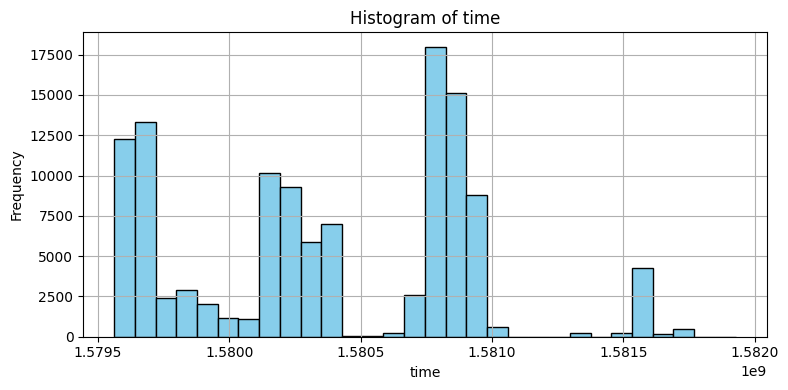

Plotting histogram for: latitude


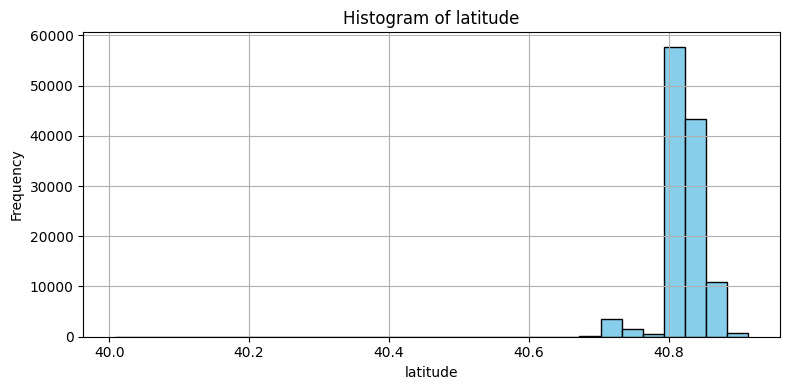

Plotting histogram for: longitude


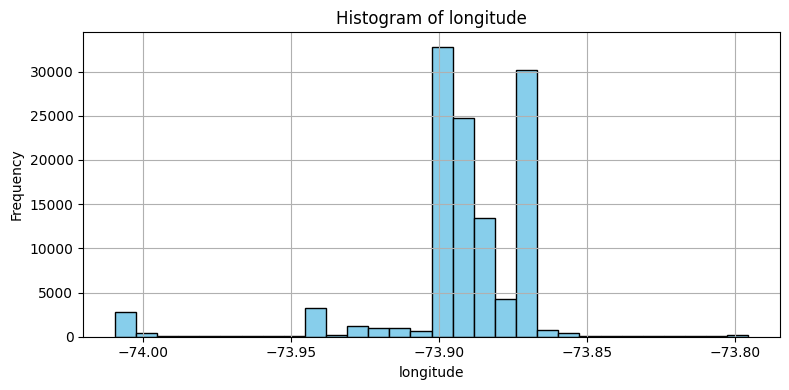

Plotting histogram for: bin0


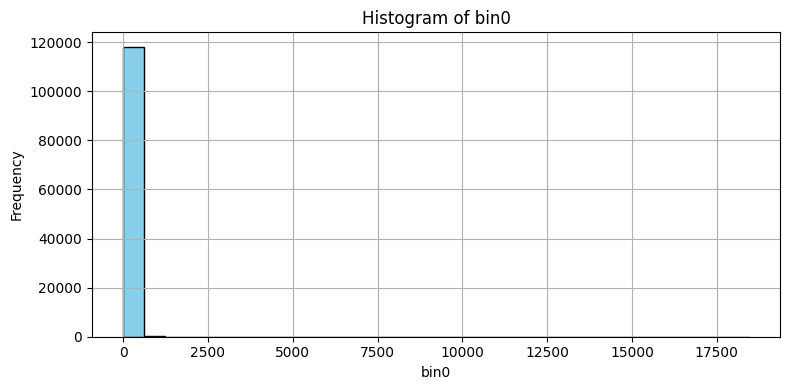

Plotting histogram for: bin1


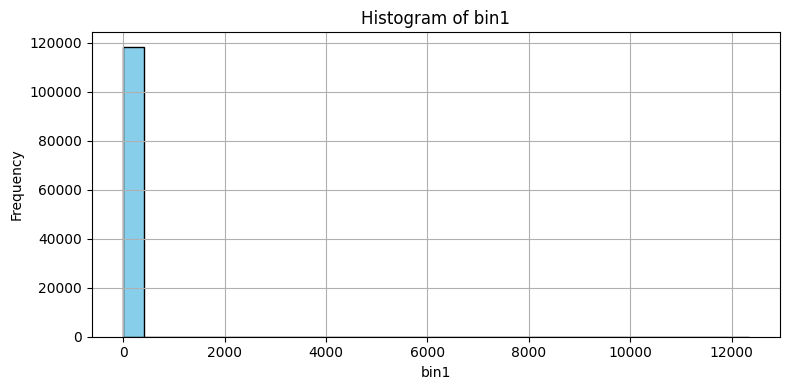

Plotting histogram for: bin2


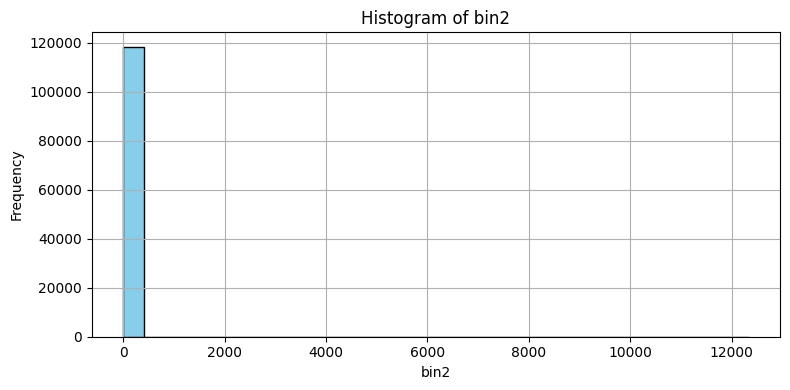

Plotting histogram for: bin3


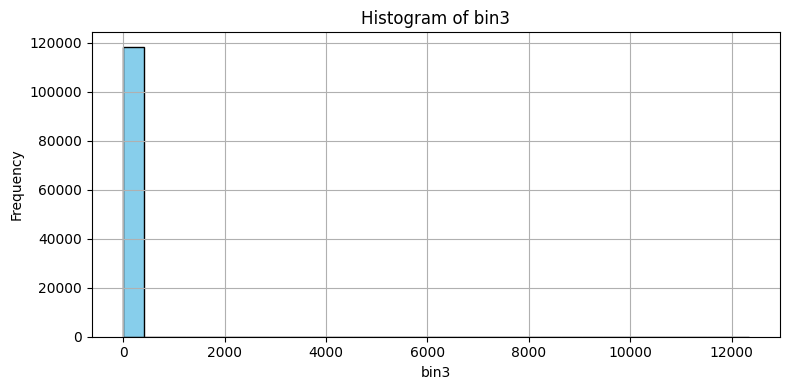

Plotting histogram for: bin4


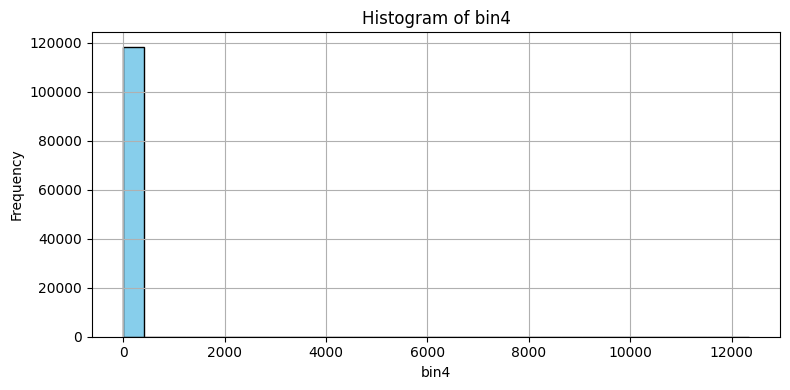

Plotting histogram for: bin5


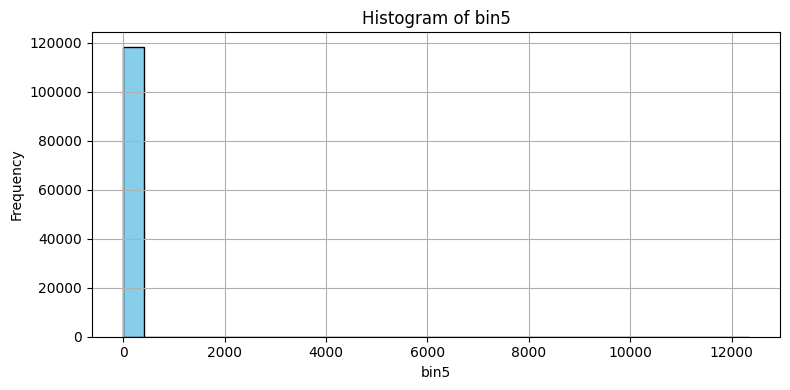

Plotting histogram for: bin6


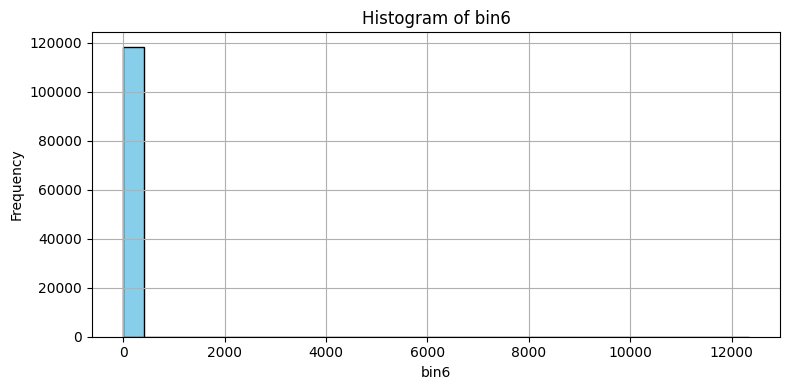

Plotting histogram for: bin7


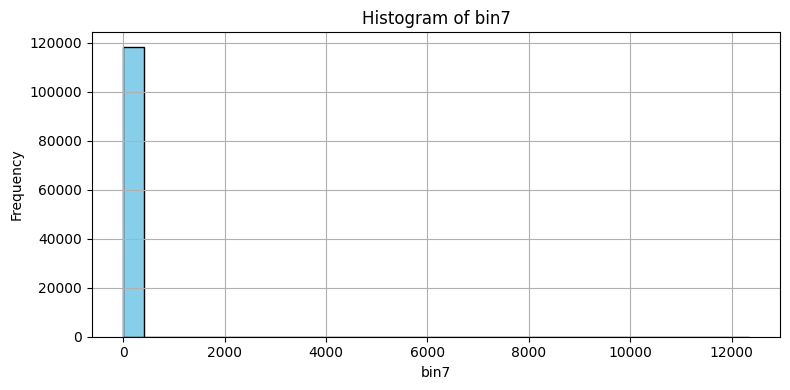

Plotting histogram for: bin8


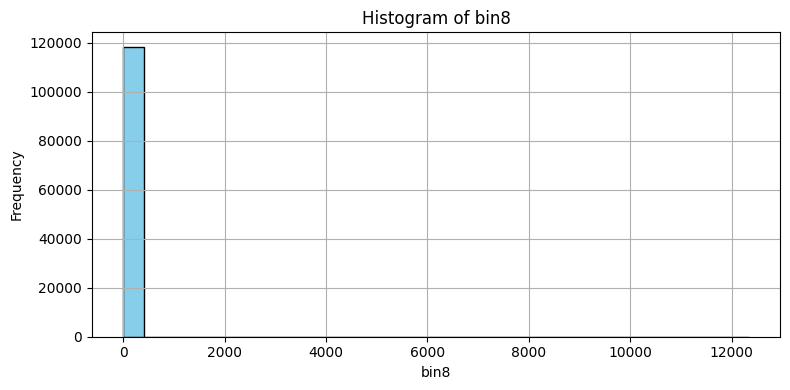

Plotting histogram for: bin9


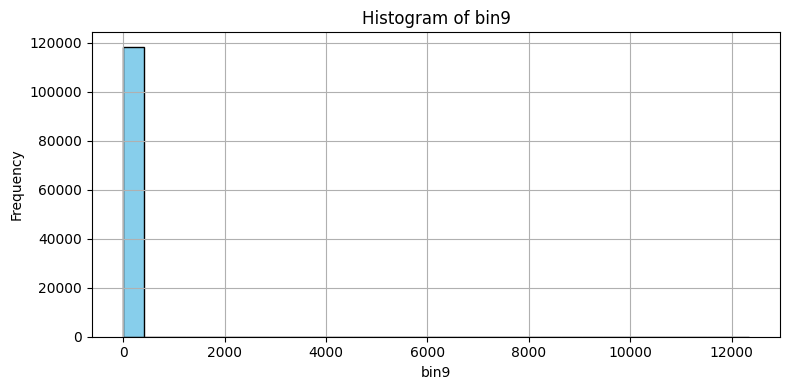

Plotting histogram for: bin10


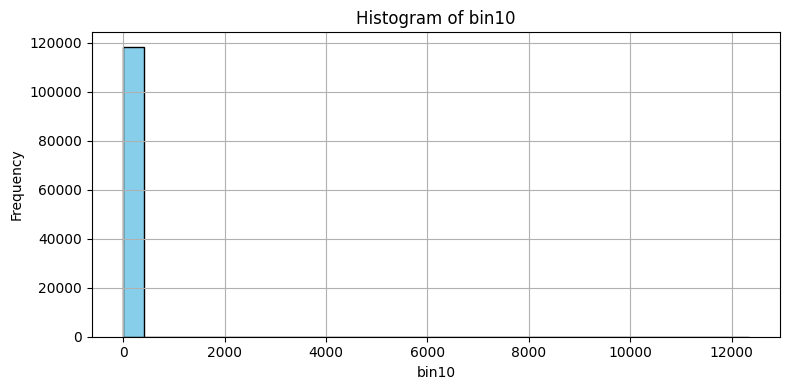

Plotting histogram for: bin11


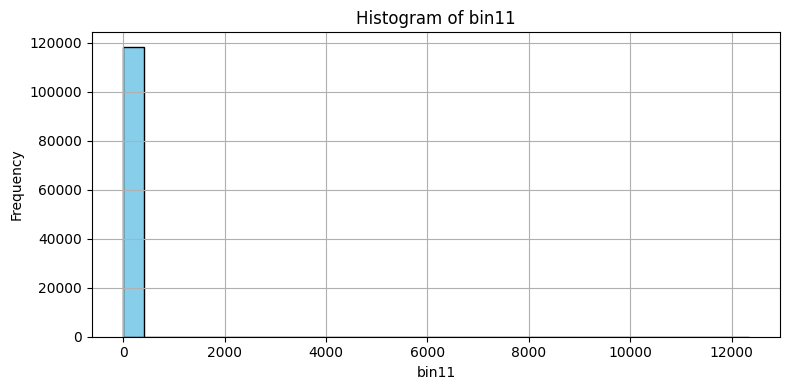

Plotting histogram for: bin12


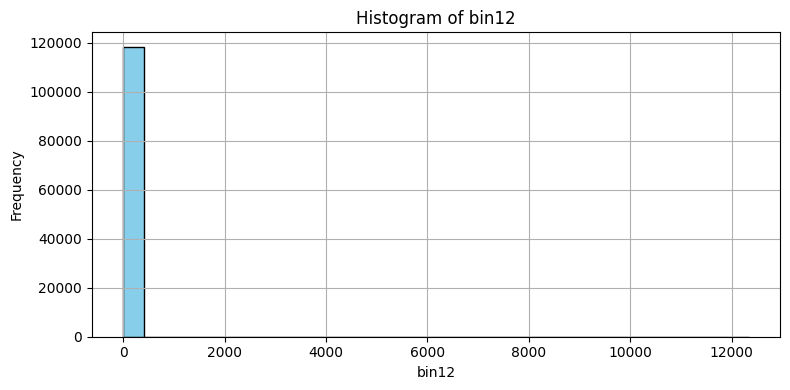

Plotting histogram for: bin13


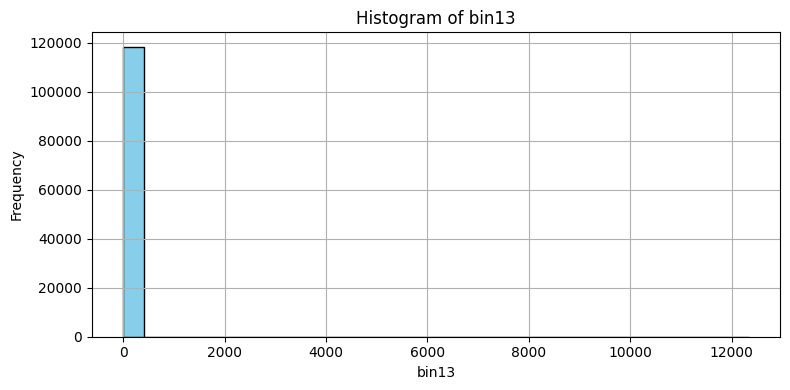

Plotting histogram for: bin14


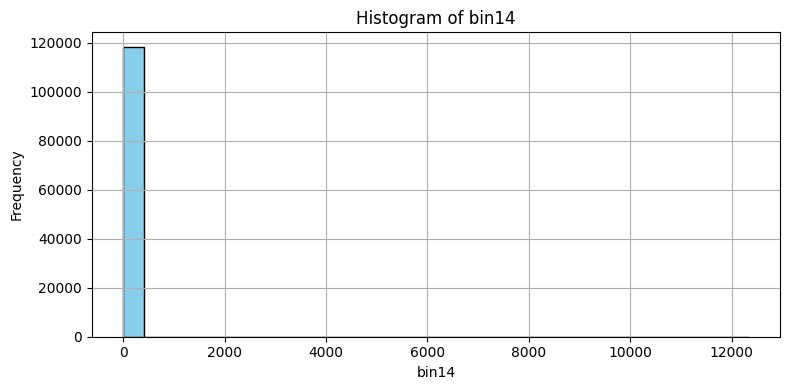

Plotting histogram for: bin15


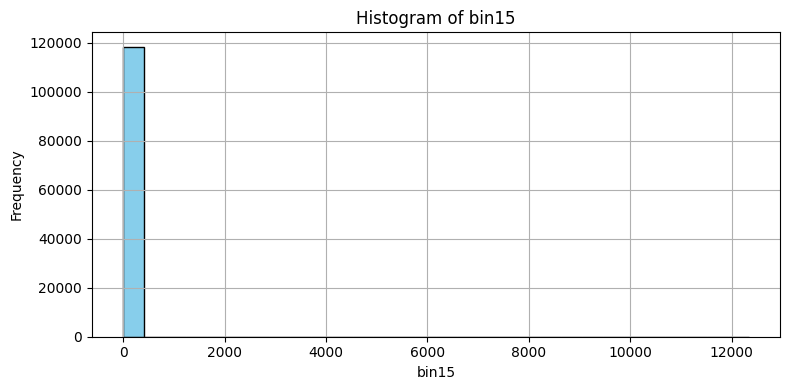

Plotting histogram for: bin16


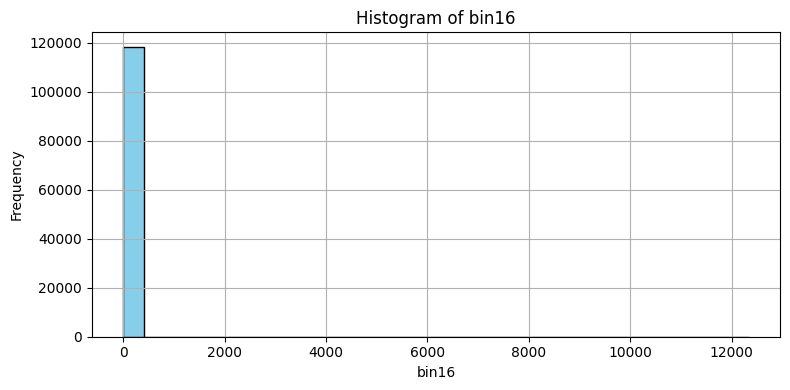

Plotting histogram for: bin17


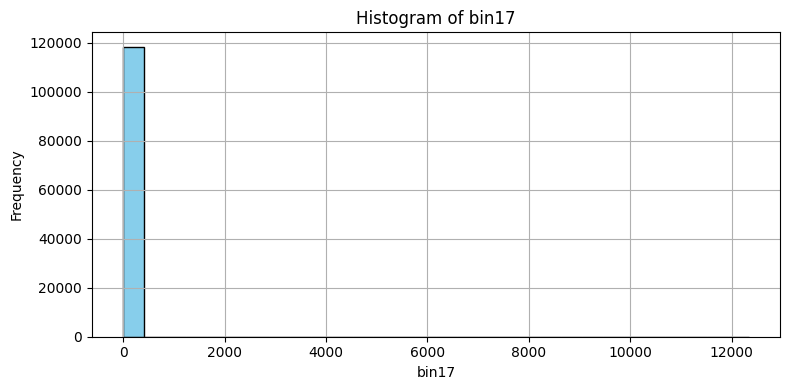

Plotting histogram for: bin18


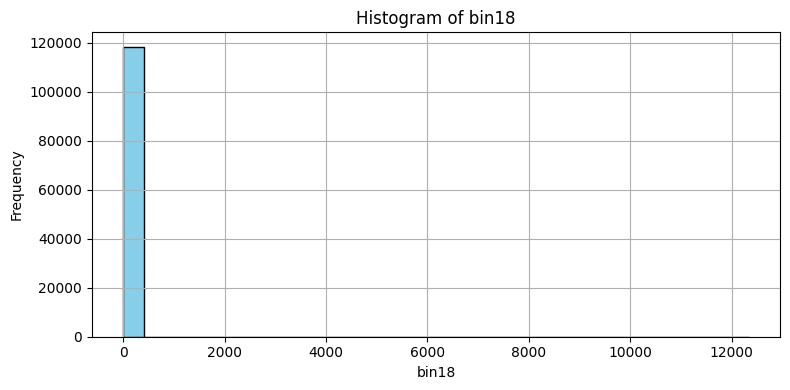

Plotting histogram for: bin19


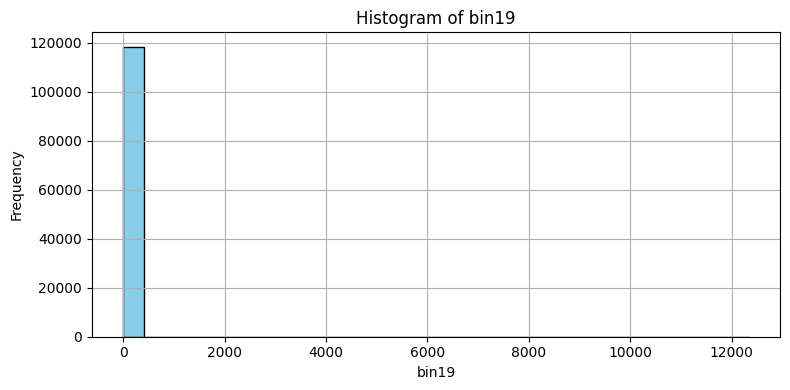

Plotting histogram for: bin20


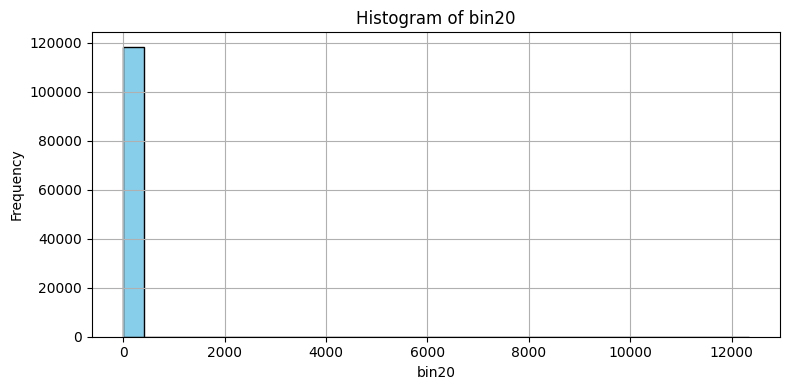

Plotting histogram for: bin21


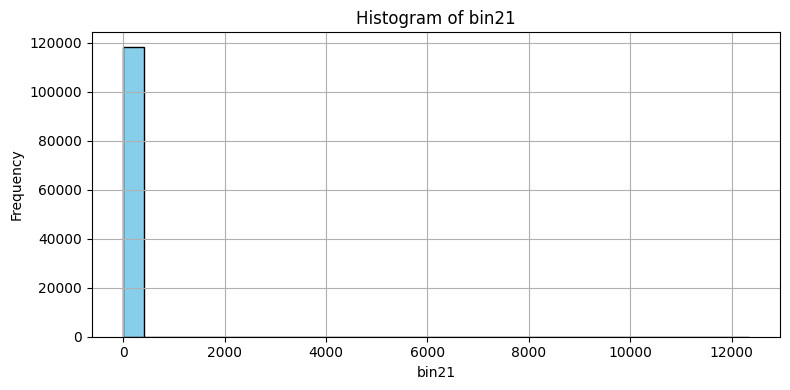

Plotting histogram for: bin22


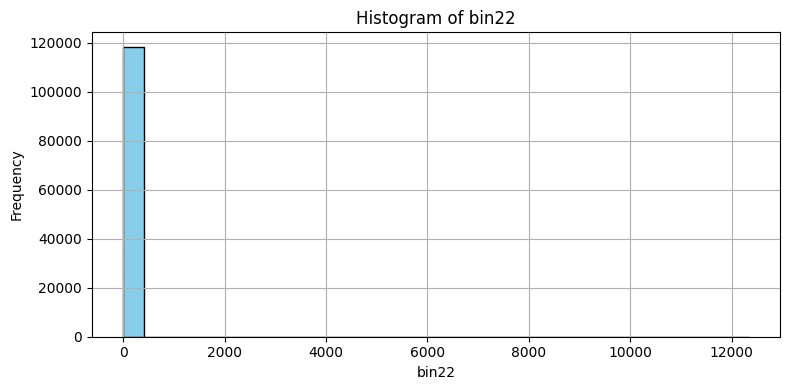

Plotting histogram for: bin23


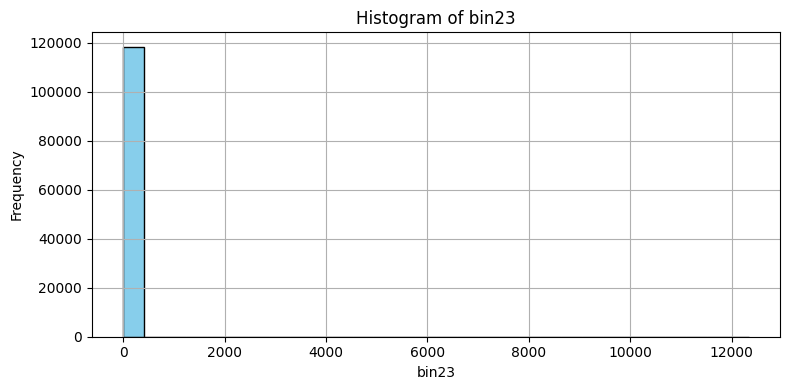

Plotting histogram for: temperature


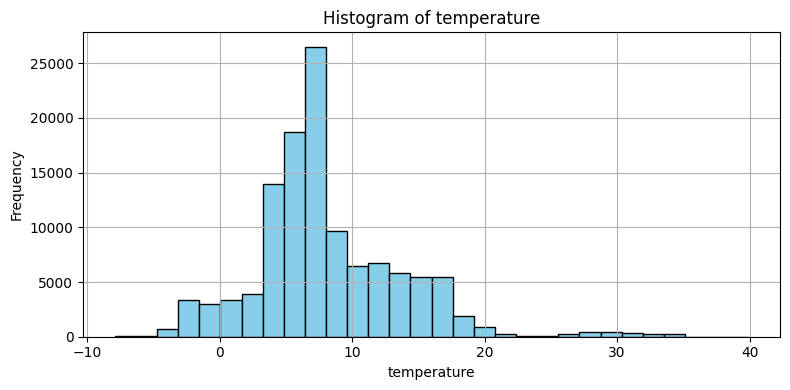

Plotting histogram for: humidity


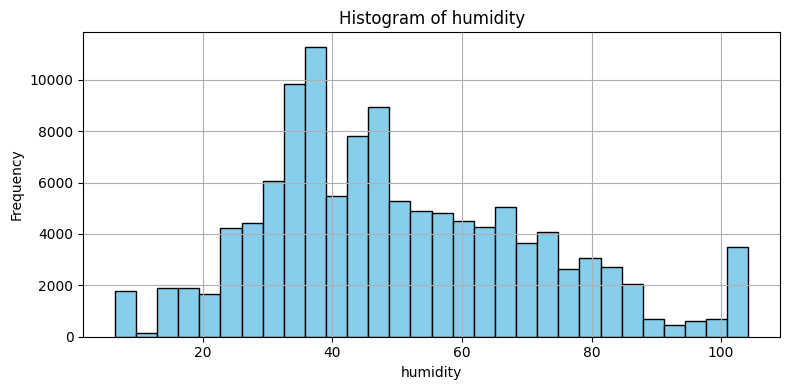

Plotting histogram for: pm25


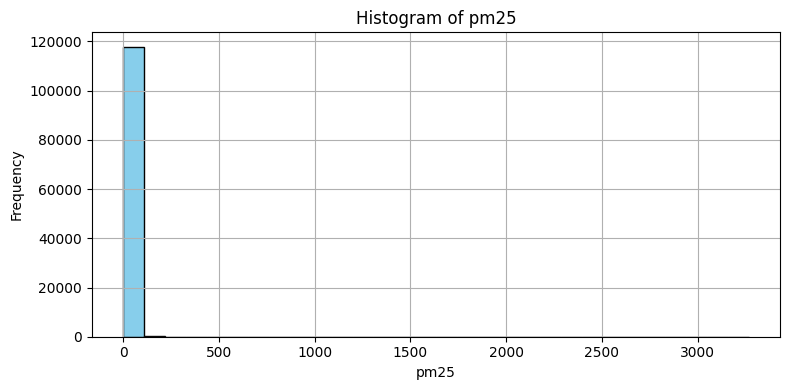

Plotting histogram for: pm1


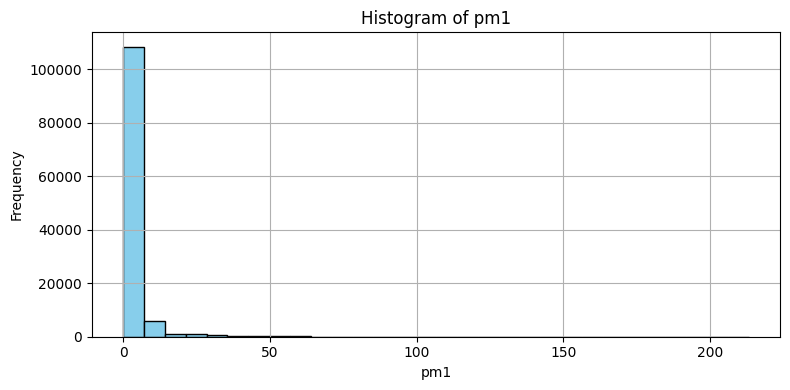

Plotting histogram for: pm10


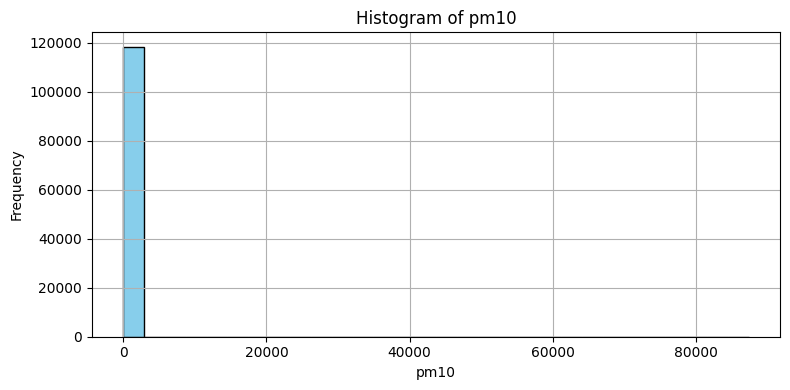

In [6]:
# Step 5: Plot histograms for each numeric column in the dataset

# Ensure inline plotting in Google Colab
%matplotlib inline

import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include='number')

print("Histograms for All Numeric Columns:")

# Check and plot
if not numeric_df.empty:
    for col in numeric_df.columns:
        print(f"Plotting histogram for: {col}")
        plt.figure(figsize=(8, 4))
        plt.hist(numeric_df[col].dropna(), bins=30, color='skyblue', edgecolor='black')
        plt.title(f"Histogram of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        plt.close()
else:
    print("No numeric columns found in the dataset.")

# Expected output:
# A sequence of individual histograms will be displayed — one for each numeric column such as:
# 'temperature', 'humidity', 'pm25', 'bin0', ..., 'bin23', 'Cluster', etc.
# Each histogram shows the frequency distribution of values in that column.

Enhanced Boxplots for Numeric Columns (excluding time and bins):


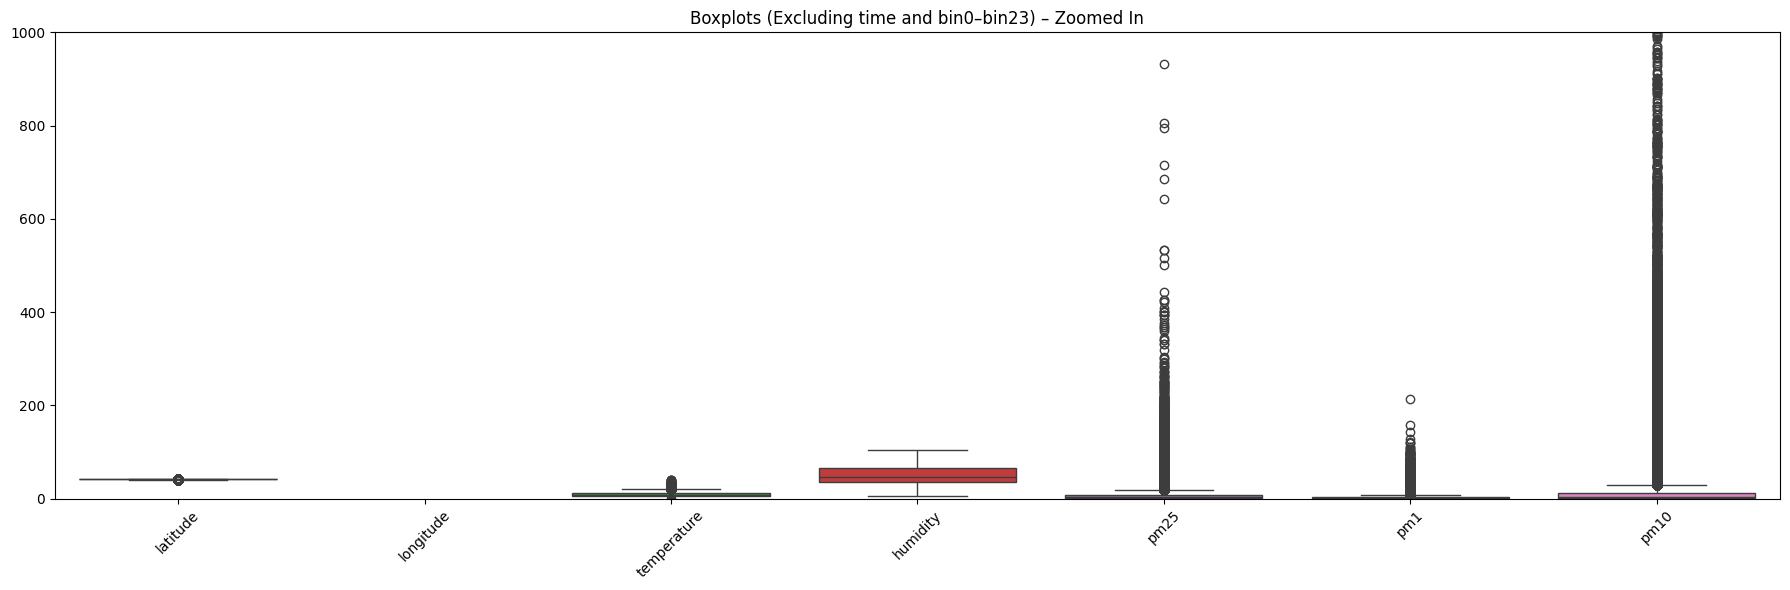

In [7]:
# Step 6: Plot enhanced boxplots (excluding time and bin0–bin23, zoomed y-axis)

%matplotlib inline

import seaborn as sns
import matplotlib.pyplot as plt

# Step 6.1: Select numeric columns
numeric_df = df.select_dtypes(include='number')

# Step 6.2: Exclude time and bin0–bin23 columns
columns_to_exclude = [f'bin{i}' for i in range(24)] + ['time']
columns_to_keep = [col for col in numeric_df.columns if col not in columns_to_exclude]

filtered_df = numeric_df[columns_to_keep]

print("Enhanced Boxplots for Numeric Columns (excluding time and bins):")

# Step 6.3: Plot with y-axis zoom (ignoring extreme outliers above 1000)
if not filtered_df.empty:
    plt.figure(figsize=(18, 6))
    sns.boxplot(data=filtered_df)
    plt.title("Boxplots (Excluding time and bin0–bin23) – Zoomed In")
    plt.ylim(0, 1000)  # Adjust this if needed
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns available for plotting.")

In [8]:
# Step 7: Plot time-series data if 'timestamp' column exists in the dataset

# Ensure inline plotting is active
%matplotlib inline

import matplotlib.pyplot as plt
import pandas as pd

# Check if timestamp column is present
if 'timestamp' in df.columns:
    print("Generating Time-Series Plot...")

    # Convert to datetime format if not already
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

    # Drop rows with invalid timestamps
    df = df.dropna(subset=['timestamp'])

    # Set timestamp as index
    df.set_index('timestamp', inplace=True)

    # Plot all numeric columns over time
    df.select_dtypes(include='number').plot(figsize=(18, 6), title="Time-Series Plot")
    plt.xlabel("Timestamp")
    plt.ylabel("Values")
    plt.tight_layout()
    plt.show()

else:
    print("No 'timestamp' column found. Skipping time-series plot.")

# Expected output:
# A multi-line time-series graph with the x-axis as timestamps and y-axis showing values
# for numeric columns like temperature, pm25, humidity, etc.
# If the column doesn't exist, it prints a skip message.

No 'timestamp' column found. Skipping time-series plot.


Correlation Matrix Heatmap:


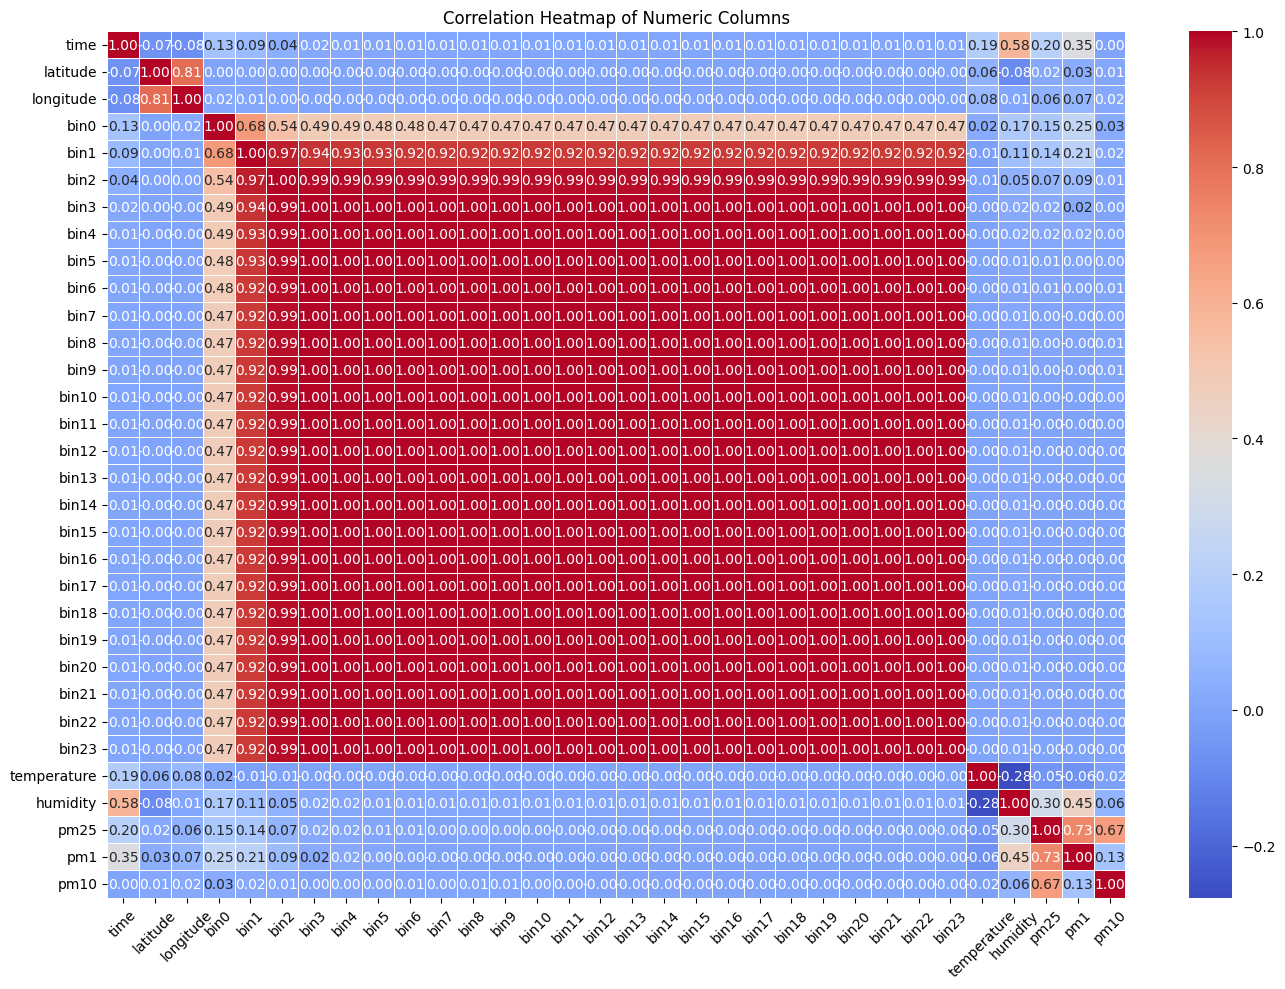

In [9]:
# Step 8: Generate a correlation heatmap between all numeric columns

# Ensure inline plotting is active
%matplotlib inline

import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns only
numeric_df = df.select_dtypes(include='number')

print("Correlation Matrix Heatmap:")

# Check if we have numeric columns to correlate
if not numeric_df.empty:
    plt.figure(figsize=(14, 10))
    correlation_matrix = numeric_df.corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title("Correlation Heatmap of Numeric Columns")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns found to compute correlation.")

# Expected output:
# A heatmap showing the Pearson correlation coefficients between all pairs of numeric columns.
# Helps identify which variables are highly related (positive or negative).

K-Means Clustering and Linear Regression Modeling:


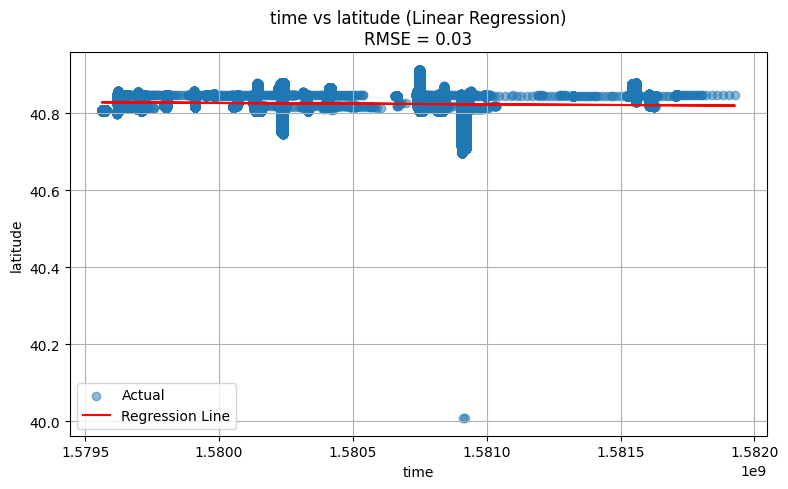

In [10]:
# Step 9: K-Means clustering and simple linear regression (fixed RMSE calculation)

# Ensure inline plotting is active
%matplotlib inline

from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Select numeric columns and drop missing values
numeric_df = df.select_dtypes(include='number').dropna()

print("K-Means Clustering and Linear Regression Modeling:")

# Proceed if at least 2 numeric columns exist
if numeric_df.shape[1] >= 2:
    # K-Means clustering
    kmeans = KMeans(n_clusters=3, random_state=42)
    df['Cluster'] = kmeans.fit_predict(numeric_df)

    # Simple linear regression between first two numeric features
    x_col = numeric_df.columns[0]
    y_col = numeric_df.columns[1]

    model = LinearRegression()
    model.fit(numeric_df[[x_col]], numeric_df[y_col])
    y_pred = model.predict(numeric_df[[x_col]])

    # Calculate RMSE manually (for compatibility)
    mse = mean_squared_error(numeric_df[y_col], y_pred)
    rmse = np.sqrt(mse)

    # Plot the regression result
    plt.figure(figsize=(8, 5))
    plt.scatter(numeric_df[x_col], numeric_df[y_col], alpha=0.5, label='Actual')
    plt.plot(numeric_df[x_col], y_pred, color='red', label='Regression Line')
    plt.title(f"{x_col} vs {y_col} (Linear Regression)\nRMSE = {rmse:.2f}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns for regression or clustering.")

RMSE vs. Sample Size Plot:


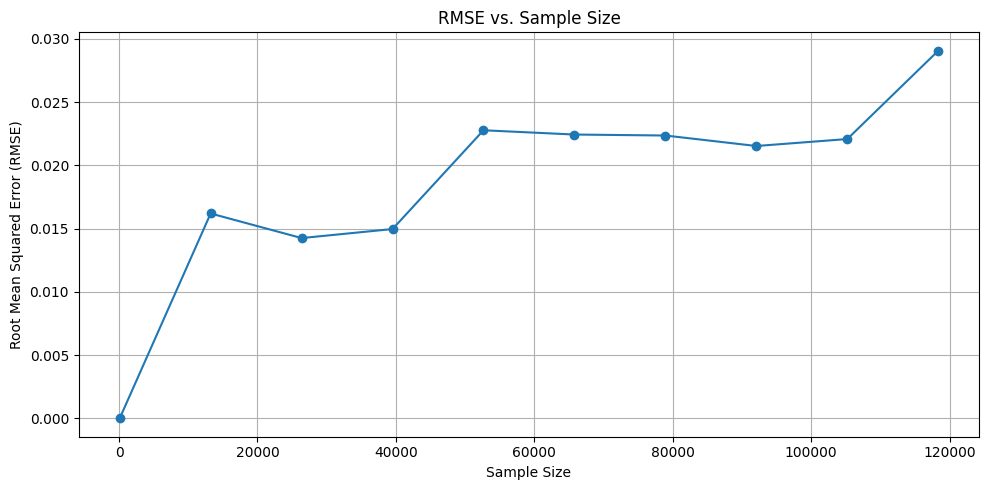

In [11]:
# Step 10: RMSE vs. Sample Size Plot using simple linear regression

# Ensure inline plotting is active
%matplotlib inline

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Select numeric columns and remove missing values
numeric_df = df.select_dtypes(include='number').dropna()

print("RMSE vs. Sample Size Plot:")

# Proceed only if dataset is large enough
if numeric_df.shape[0] >= 100 and numeric_df.shape[1] >= 2:
    x_col = numeric_df.columns[0]
    y_col = numeric_df.columns[1]

    sample_sizes = np.linspace(100, len(numeric_df), 10, dtype=int)
    rmses = []

    for size in sample_sizes:
        subset = numeric_df.iloc[:size]
        model = LinearRegression()
        model.fit(subset[[x_col]], subset[y_col])
        prediction = model.predict(subset[[x_col]])
        mse = mean_squared_error(subset[y_col], prediction)
        rmse = np.sqrt(mse)
        rmses.append(rmse)

    # Plot RMSE vs. Sample Size
    plt.figure(figsize=(10, 5))
    plt.plot(sample_sizes, rmses, marker='o')
    plt.title("RMSE vs. Sample Size")
    plt.xlabel("Sample Size")
    plt.ylabel("Root Mean Squared Error (RMSE)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data or numeric columns to plot RMSE vs Sample Size.")

In [12]:
# Step 11: Encode latitude/longitude into geohash codes at different precisions

# Ensure inline plotting
%matplotlib inline

# Install geohash2 package (compatible and stable)
!pip install geohash2

import geohash2

print("Geohash Spatial Encoding:")

# Check for lat/lon columns
if {'latitude', 'longitude'}.issubset(df.columns):
    # Drop rows with missing coordinates
    df = df.dropna(subset=['latitude', 'longitude'])

    # Encode into geohash at precision levels 5 (coarse) and 7 (finer)
    df['geohash_5'] = df.apply(lambda row: geohash2.encode(row['latitude'], row['longitude'], precision=5), axis=1)
    df['geohash_7'] = df.apply(lambda row: geohash2.encode(row['latitude'], row['longitude'], precision=7), axis=1)

    # Preview the output
    print("Sample rows with geohash codes:")
    display(df[['latitude', 'longitude', 'geohash_5', 'geohash_7']].head())
else:
    print("Missing 'latitude' or 'longitude' — cannot generate geohash.")

  Preparing metadata (setup.py) ... done
  Created wheel for geohash2: filename=geohash2-1.1-py3-none-any.whl size=15543 sha256=620cc8e7cd78aff2b306dc5b8837481e73eb337af3ae75985952f70c1b1023e3
  Stored in directory: /root/.cache/pip/wheels/f6/7c/c4/1b3c6fea0ebc53bf730dc86bbee7a713d501455dfb4c1f0623
Successfully built geohash2
Geohash Spatial Encoding:
Sample rows with geohash codes:


,latitude,longitude,geohash_5,geohash_7
0,40.847183,-73.870087,dr72r,dr72rh1
1,40.847183,-73.870094,dr72r,dr72rh1
2,40.847179,-73.870094,dr72r,dr72rh1
3,40.847179,-73.870094,dr72r,dr72rh1
4,40.847179,-73.870094,dr72r,dr72rh1


In [13]:
# Part A: Group data by geohash and compute average air quality and weather

# Group by geohash_5 (coarser resolution) and compute means
agg_df = df.groupby('geohash_5')[['pm25', 'pm10', 'pm1', 'temperature', 'humidity']].mean().reset_index()

# Show a few rows of the aggregated result
print("Average measurements per geohash_5 region:")
display(agg_df.head())

# Expected output:
# A table showing average pm25, pm10, pm1, temperature, and humidity per geohash_5 region.

Average measurements per geohash_5 region:


,geohash_5,pm25,pm10,pm1,temperature,humidity
0,dr57w,0.140000,0.140000,0.135000,7.350000,58.350000
1,dr5re,3.193897,7.194069,1.778951,6.566809,64.891006
2,dr5rs,3.707045,12.708428,1.507202,6.737378,60.933920
3,dr5ru,0.405913,0.414522,0.316000,7.678261,57.463478
4,dr5rv,2.025832,9.847255,0.893435,7.233769,46.105084


In [14]:
# Step: Fix geohash decoding and show average air quality on map

import folium
import geohash2

# Step 1: Re-decode geohash to get clean lat/lon (as float tuples)
decoded_coords = agg_df['geohash_5'].apply(geohash2.decode)

# Step 2: Assign lat/lon correctly (not as strings)
agg_df['lat'] = decoded_coords.apply(lambda x: float(x[0]))
agg_df['lon'] = decoded_coords.apply(lambda x: float(x[1]))

# Step 3: Create map centered on average location
map_center = [agg_df['lat'].mean(), agg_df['lon'].mean()]
m = folium.Map(location=map_center, zoom_start=8)

# Step 4: Add PM2.5 + temperature markers
for _, row in agg_df.iterrows():
    popup_text = f"""
    Geohash: {row['geohash_5']}<br>
    PM2.5: {row['pm25']:.2f}<br>
    Temp: {row['temperature']:.1f}°C
    """
    folium.CircleMarker(
        location=(row['lat'], row['lon']),
        radius=6,
        fill=True,
        fill_opacity=0.7,
        popup=popup_text,
        color='blue'
    ).add_to(m)

# Show the map
m

In [15]:
colormap = plt.colormaps['YlOrRd']

In [16]:
# Step: Fix geohash decoding to lat/lon and visualize on map

import folium
import geohash2
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# Ensure 'lat' and 'lon' are correctly decoded from geohash_5
decoded_coords = agg_df['geohash_5'].apply(geohash2.decode)
agg_df['lat'] = decoded_coords.apply(lambda x: float(x[0]))
agg_df['lon'] = decoded_coords.apply(lambda x: float(x[1]))

# Normalize PM2.5 for color mapping
norm = colors.Normalize(vmin=agg_df['pm25'].min(), vmax=agg_df['pm25'].max())
colormap = plt.colormaps['YlOrRd']

# Convert PM2.5 to color hex
def get_color(value):
    rgba = colormap(norm(value))
    return colors.to_hex(rgba)

# Create the folium map
map_center = [agg_df['lat'].mean(), agg_df['lon'].mean()]
m = folium.Map(location=map_center, zoom_start=8)

# Add markers to map
for _, row in agg_df.iterrows():
    folium.CircleMarker(
        location=(row['lat'], row['lon']),
        radius=7,
        fill=True,
        fill_opacity=0.8,
        color=get_color(row['pm25']),
        fill_color=get_color(row['pm25']),
        popup=f"""
        Geohash: {row['geohash_5']}<br>
        PM2.5: {row['pm25']:.2f}<br>
        Temp: {row['temperature']:.1f}°C<br>
        Humidity: {row['humidity']:.1f}%
        """
    ).add_to(m)

# Display the map
m


In [17]:
import folium
import geohash2
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from branca.element import MacroElement
from jinja2 import Template

# Step 1: Decode geohash_5 into lat/lon (as float)
decoded_coords = agg_df['geohash_5'].apply(geohash2.decode)
agg_df['lat'] = decoded_coords.apply(lambda x: float(x[0]))
agg_df['lon'] = decoded_coords.apply(lambda x: float(x[1]))

# Step 2: Normalize PM2.5 values and choose colormap
norm = colors.Normalize(vmin=agg_df['pm25'].min(), vmax=agg_df['pm25'].max())
colormap = plt.colormaps['YlOrRd']

def get_color(value):
    rgba = colormap(norm(value))
    return colors.to_hex(rgba)

# Step 3: Create the folium map
map_center = [agg_df['lat'].mean(), agg_df['lon'].mean()]
m = folium.Map(location=map_center, zoom_start=8)

# Step 4: Add circle markers with color-coded PM2.5
for _, row in agg_df.iterrows():
    folium.CircleMarker(
        location=(row['lat'], row['lon']),
        radius=7,
        fill=True,
        fill_opacity=0.8,
        color=get_color(row['pm25']),
        fill_color=get_color(row['pm25']),
        popup=f"""
        <b>Geohash:</b> {row['geohash_5']}<br>
        <b>PM2.5:</b> {row['pm25']:.2f}<br>
        <b>Temp:</b> {row['temperature']:.1f}°C<br>
        <b>Humidity:</b> {row['humidity']:.1f}%
        """
    ).add_to(m)

# Step 5: Add custom legend (color scale bar)
legend_html = """
{% macro html(this, kwargs) %}
<div style="
    position: fixed;
    bottom: 30px;
    left: 30px;
    width: 170px;
    height: 180px;
    z-index:9999;
    font-size:14px;
    background-color: white;
    padding: 10px;
    border: 2px solid gray;
    border-radius: 5px;">
    <b>PM2.5 Scale</b><br>
    <i style="background:#ffffb2;width:18px;height:18px;display:inline-block"></i> Low<br>
    <i style="background:#fecc5c;width:18px;height:18px;display:inline-block"></i> Moderate<br>
    <i style="background:#fd8d3c;width:18px;height:18px;display:inline-block"></i> High<br>
    <i style="background:#f03b20;width:18px;height:18px;display:inline-block"></i> Very High<br>
    <i style="background:#bd0026;width:18px;height:18px;display:inline-block"></i> Hazardous
</div>
{% endmacro %}
"""

class Legend(MacroElement):
    def __init__(self):
        super().__init__()
        self._template = Template(legend_html)

# Step 6: Add legend to the map
m.get_root().add_child(Legend())

# Step 7: Display map
m